In [1]:
import mlflow

mlflow.set_tracking_uri("file:./mlruns")

In [2]:
# Set or create an experiment
mlflow.set_experiment("ML Algos with HP Tuning")

c:\Users\Soham\Documents\youtube comment analyzer\yt_env\Lib\site-packages\mlflow\tracking\_tracking_service\utils.py:184: FutureWarning: The filesystem tracking backend (e.g., './mlruns') is deprecated as of February 2026. Consider transitioning to a database backend (e.g., 'sqlite:///mlflow.db') to take advantage of the latest MLflow features. See https://mlflow.org/docs/latest/self-hosting/migrate-from-file-store for migration guidance.
  return FileStore(store_uri, store_uri)


<Experiment: artifact_location=('file:c:/Users/Soham/Documents/youtube comment '
 'analyzer/mlruns/901947899065852447'), creation_time=1778952120616, experiment_id='901947899065852447', last_update_time=1778952120616, lifecycle_stage='active', name='ML Algos with HP Tuning', tags={}, trace_location=None, workspace='default'>

In [3]:
# =========================================================
# IMPORTS
# =========================================================
import mlflow
import mlflow.sklearn
import optuna
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split

from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    f1_score
)

from imblearn.over_sampling import SMOTE

from lightgbm import LGBMClassifier

In [15]:
df = pd.read_csv('reddit_preprocessing.csv').dropna()
df.shape

(36662, 2)

In [16]:
print(df['category'].unique())

[ 1 -1  0]


In [11]:
print(df['category'].value_counts())

category
 1    15770
 0    12644
-1     8248
Name: count, dtype: int64


In [14]:
print(df['category'].unique())

print(df['category'].value_counts())

[1. 0.]
category
1.0    15770
0.0    12644
Name: count, dtype: int64


[I 2026-05-17 17:23:03,723] A new study created in memory with name: no-name-058f2be0-c928-427f-a54d-caf9fd7224f3


ORIGINAL CLASSES:
[ 1 -1  0]

CLASS COUNTS:

category
 1    15770
 0    12644
-1     8248
Name: count, dtype: int64

TRAIN CLASS COUNTS:

category
 1    12616
 0    10115
-1     6598
Name: count, dtype: int64

TEST CLASS COUNTS:

category
 1    3154
 0    2529
-1    1650
Name: count, dtype: int64


c:\Users\Soham\Documents\youtube comment analyzer\yt_env\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\Soham\Documents\youtube comment analyzer\yt_env\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\Soham\Documents\youtube comment analyzer\yt_env\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
[I 2026-05-17 17:23:30,499] Trial 0 finished with value: 0.7226096491379681 and parameters: {'n_estimators': 127, 'learning_rate': 0.05251844088987687, 'max_depth': 7, 'num_leaves': 46, 'min_child_samples': 27, 'reg_alpha': 0.3100688100479776, 'reg_lambda': 3.1192287999557404, 'subsample': 0.7365988240982612, 'colsample_byt

BEST PARAMETERS
{'n_estimators': 337, 'learning_rate': 0.11928540888394856, 'max_depth': 8, 'num_leaves': 44, 'min_child_samples': 27, 'reg_alpha': 0.5276559415522459, 'reg_lambda': 3.018003406544187, 'subsample': 0.7583164078906648, 'colsample_bytree': 0.9386179762298097}


c:\Users\Soham\Documents\youtube comment analyzer\yt_env\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(



PREDICTED CLASSES:
[-1  0  1]

Accuracy    : 0.8308
Macro F1    : 0.8186
Weighted F1 : 0.8291

Classification Report:

              precision    recall  f1-score   support

          -1       0.77      0.72      0.75      1650
           0       0.79      0.96      0.87      2529
           1       0.91      0.78      0.84      3154

    accuracy                           0.83      7333
   macro avg       0.82      0.82      0.82      7333
weighted avg       0.84      0.83      0.83      7333


CONFUSION MATRIX SHAPE:
(3, 3)


2026/05/17 17:42:50 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


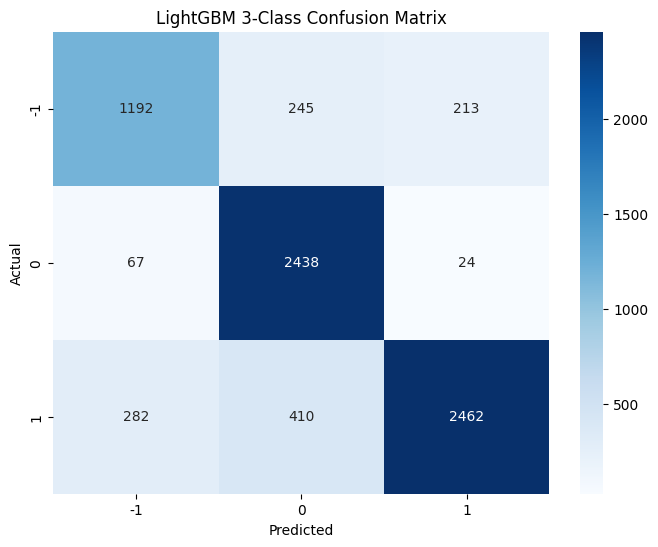

In [2]:
# =========================================================
# IMPORTS
# =========================================================
import numpy as np
import pandas as pd
import optuna
import mlflow

from lightgbm import LGBMClassifier

from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    cross_val_score
)

from sklearn.pipeline import Pipeline

from sklearn.feature_extraction.text import (
    TfidfVectorizer
)

from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix
)

import matplotlib.pyplot as plt
import seaborn as sns

# =========================================================
# RANDOM SEED
# =========================================================
np.random.seed(42)

# =========================================================
# LOAD ORIGINAL DATASET
# =========================================================
df_original = pd.read_csv(
    "reddit_preprocessing.csv"
).dropna()

# =========================================================
# SAFE COPY
# =========================================================
df = df_original.copy()

# =========================================================
# VERIFY CLASSES
# =========================================================
print("=" * 60)

print("ORIGINAL CLASSES:")

print(df['category'].unique())

print("\nCLASS COUNTS:\n")

print(df['category'].value_counts())

print("=" * 60)

# =========================================================
# IMPORTANT:
# KEEP ORIGINAL LABELS (-1, 0, 1)
# DO NOT MAP THEM
# =========================================================

# =========================================================
# FEATURES / TARGET
# =========================================================
X_text = df['clean_comment']

y = df['category']

# =========================================================
# TRAIN TEST SPLIT
# =========================================================
X_train_text, X_test_text, y_train, y_test = train_test_split(

    X_text,

    y,

    test_size=0.2,

    random_state=42,

    stratify=y
)

# =========================================================
# VERIFY SPLIT
# =========================================================
print("\nTRAIN CLASS COUNTS:\n")

print(y_train.value_counts())

print("\nTEST CLASS COUNTS:\n")

print(y_test.value_counts())

# =========================================================
# TF-IDF SETTINGS
# =========================================================
ngram_range = (1, 3)

max_features = 5000

# =========================================================
# CROSS VALIDATION
# =========================================================
cv = StratifiedKFold(

    n_splits=3,

    shuffle=True,

    random_state=42
)

# =========================================================
# MLFLOW EXPERIMENT
# =========================================================
mlflow.set_experiment(
    "LightGBM_3Class_Classification"
)

# =========================================================
# OPTUNA OBJECTIVE FUNCTION
# =========================================================
def objective_lightgbm(trial):

    params = {

        "n_estimators": trial.suggest_int(
            "n_estimators",
            100,
            400
        ),

        "learning_rate": trial.suggest_float(
            "learning_rate",
            0.01,
            0.15,
            log=True
        ),

        "max_depth": trial.suggest_int(
            "max_depth",
            3,
            10
        ),

        "num_leaves": trial.suggest_int(
            "num_leaves",
            20,
            120
        ),

        "min_child_samples": trial.suggest_int(
            "min_child_samples",
            10,
            60
        ),

        "reg_alpha": trial.suggest_float(
            "reg_alpha",
            0.0,
            5.0
        ),

        "reg_lambda": trial.suggest_float(
            "reg_lambda",
            0.0,
            5.0
        ),

        "subsample": trial.suggest_float(
            "subsample",
            0.7,
            0.95
        ),

        "colsample_bytree": trial.suggest_float(
            "colsample_bytree",
            0.7,
            0.95
        ),

        # =================================================
        # MULTICLASS SETTINGS
        # =================================================
        "objective": "multiclass",

        "num_class": 3,

        "class_weight": "balanced",

        "random_state": 42,

        "n_jobs": 4,

        "verbosity": -1
    }

    # =====================================================
    # PIPELINE
    # =====================================================
    pipeline = Pipeline([

        (
            "tfidf",

            TfidfVectorizer(

                ngram_range=ngram_range,

                max_features=max_features,

                min_df=3,

                max_df=0.90,

                sublinear_tf=True
            )
        ),

        (
            "model",

            LGBMClassifier(
                **params
            )
        )
    ])

    # =====================================================
    # CROSS VALIDATION
    # =====================================================
    scores = cross_val_score(

        pipeline,

        X_train_text,

        y_train,

        cv=cv,

        scoring='f1_macro',

        n_jobs=1
    )

    return np.mean(scores)

# =========================================================
# RUN OPTUNA
# =========================================================
study = optuna.create_study(
    direction="maximize"
)

study.optimize(

    objective_lightgbm,

    n_trials=30
)

# =========================================================
# BEST PARAMETERS
# =========================================================
print("=" * 60)

print("BEST PARAMETERS")

print(study.best_params)

print("=" * 60)

# =========================================================
# FINAL PIPELINE
# =========================================================
best_pipeline = Pipeline([

    (
        "tfidf",

        TfidfVectorizer(

            ngram_range=ngram_range,

            max_features=max_features,

            min_df=3,

            max_df=0.90,

            sublinear_tf=True
        )
    ),

    (
        "model",

        LGBMClassifier(

            **study.best_params,

            objective="multiclass",

            num_class=3,

            class_weight='balanced',

            random_state=42,

            n_jobs=4,

            verbosity=-1
        )
    )
])

# =========================================================
# TRAIN FINAL MODEL
# =========================================================
best_pipeline.fit(

    X_train_text,

    y_train
)

# =========================================================
# PREDICTIONS
# =========================================================
y_pred = best_pipeline.predict(
    X_test_text
)

# =========================================================
# VERIFY PREDICTED CLASSES
# =========================================================
print("\nPREDICTED CLASSES:")

print(np.unique(y_pred))

# =========================================================
# METRICS
# =========================================================
accuracy = accuracy_score(
    y_test,
    y_pred
)

macro_f1 = f1_score(

    y_test,

    y_pred,

    average='macro'
)

weighted_f1 = f1_score(

    y_test,

    y_pred,

    average='weighted'
)

# =========================================================
# RESULTS
# =========================================================
print(f"\nAccuracy    : {accuracy:.4f}")

print(f"Macro F1    : {macro_f1:.4f}")

print(f"Weighted F1 : {weighted_f1:.4f}")

# =========================================================
# CLASSIFICATION REPORT
# =========================================================
print("\nClassification Report:\n")

print(
    classification_report(
        y_test,
        y_pred
    )
)

# =========================================================
# CONFUSION MATRIX
# =========================================================
conf_matrix = confusion_matrix(
    y_test,
    y_pred
)

print("\nCONFUSION MATRIX SHAPE:")

print(conf_matrix.shape)

fig, ax = plt.subplots(figsize=(8,6))

sns.heatmap(

    conf_matrix,

    annot=True,

    fmt='d',

    cmap='Blues',

    xticklabels=[-1, 0, 1],

    yticklabels=[-1, 0, 1],

    ax=ax
)

ax.set_xlabel("Predicted")

ax.set_ylabel("Actual")

ax.set_title("LightGBM 3-Class Confusion Matrix")

# =========================================================
# MLFLOW LOGGING
# =========================================================
with mlflow.start_run(
    run_name="LightGBM_3Class"
):

    mlflow.log_params(
        study.best_params
    )

    mlflow.log_metric(
        "accuracy",
        accuracy
    )

    mlflow.log_metric(
        "macro_f1",
        macro_f1
    )

    mlflow.log_metric(
        "weighted_f1",
        weighted_f1
    )

    mlflow.log_figure(
        fig,
        "lightgbm_3class_confusion_matrix.png"
    )

    mlflow.sklearn.log_model(

        sk_model=best_pipeline,

        name="lightgbm_pipeline"
    )

plt.show()

plt.close(fig)